In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

In [3]:
from src.labeling import add_returns, add_volatility, add_volatility_regime
from src.features import (
    add_target_direction,
    add_lagged_returns,
    add_moving_average_features,
    add_volatility_features
)

In [4]:
df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

df = add_returns(df)
df = add_volatility(df)
df = add_volatility_regime(df)

df = add_target_direction(df)
df = add_lagged_returns(df)
df = add_moving_average_features(df)
df = add_volatility_features(df)

df_feat = df.dropna().copy()

In [5]:
model_cols = [
    "target",
    "ret_lag_1","ret_lag_5","ret_lag_10",
    "ma_ratio_5","ma_ratio_10","ma_ratio_20",
    "volatility","vol_lag_1",
    "vol_regime"
]

df_model = df_feat[model_cols].copy()

In [6]:
years = sorted(df_model.index.year.unique())

years

[2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025,
 2026]

In [7]:
results = []

min_train_years = 5  # require initial history

for year in years:
    
    train_mask = df_model.index.year < year
    test_mask  = df_model.index.year == year
    
    train = df_model[train_mask]
    test  = df_model[test_mask]
    
    if len(train) == 0 or len(test) == 0:
        continue
    
    if train.index.year.nunique() < min_train_years:
        continue
    
    # separate
    X_train = train.drop(columns=["target","vol_regime"])
    y_train = train["target"]
    
    X_test = test.drop(columns=["target","vol_regime"])
    y_test = test["target"]
    
    # scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, pred)
    
    results.append({
        "year": year,
        "accuracy": acc,
        "n_test": len(test)
    })

In [8]:
wf_results = pd.DataFrame(results)
wf_results

,year,accuracy,n_test
0,2012,0.483471,242
1,2013,0.522267,247
2,2014,0.525000,240
3,2015,0.512295,244
4,2016,0.479508,244
5,2017,0.508065,248
6,2018,0.551020,245
7,2019,0.502075,241
8,2020,0.560000,250
9,2021,0.584677,248


In [9]:
mean_acc = wf_results["accuracy"].mean()
std_acc  = wf_results["accuracy"].std()

print("Mean accuracy:", mean_acc)
print("Std accuracy :", std_acc)

Mean accuracy: 0.522680654229345
Std accuracy : 0.03875507609095486


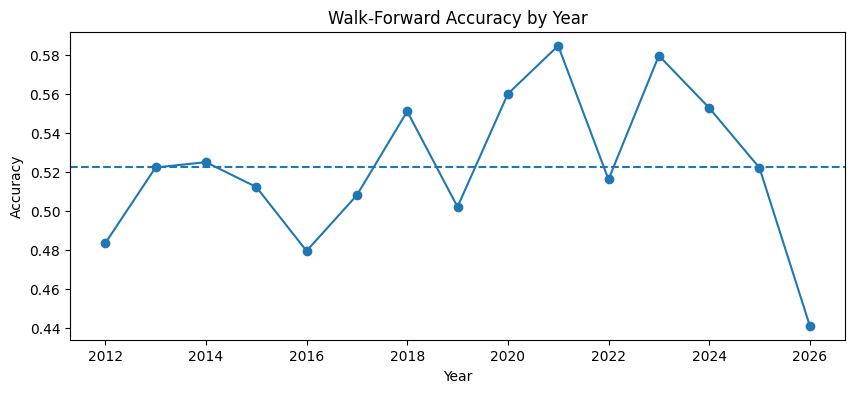

In [10]:
plt.figure(figsize=(10,4))
plt.plot(wf_results["year"], wf_results["accuracy"], marker="o")
plt.axhline(mean_acc, linestyle="--")
plt.title("Walk-Forward Accuracy by Year")
plt.xlabel("Year")
plt.ylabel("Accuracy")
plt.show()

In [11]:
regime_results = []

for year in years:
    
    train_mask = df_model.index.year < year
    test_mask  = df_model.index.year == year
    
    train = df_model[train_mask]
    test  = df_model[test_mask]
    
    if len(train) == 0 or len(test) == 0:
        continue
    
    if train.index.year.nunique() < min_train_years:
        continue
    
    X_train = train.drop(columns=["target","vol_regime"])
    y_train = train["target"]
    
    X_test = test.drop(columns=["target","vol_regime"])
    y_test = test["target"]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    pred = model.predict(X_test_scaled)
    
    test_eval = test.copy()
    test_eval["pred"] = pred
    
    for regime, group in test_eval.groupby("vol_regime"):
        acc = accuracy_score(group["target"], group["pred"])
        
        regime_results.append({
            "year": year,
            "regime": regime,
            "accuracy": acc,
            "n": len(group)
        })

In [14]:
wf_regime = pd.DataFrame(regime_results)
wf_regime.head(10)

,year,regime,accuracy,n
0,2012,High,0.550000,80
1,2012,Low,0.428571,49
2,2012,Medium,0.460177,113
3,2013,High,0.515464,97
4,2013,Low,0.545455,44
5,2013,Medium,0.518868,106
6,2014,Low,0.626506,83
7,2014,Medium,0.471338,157
8,2015,High,0.534247,73
9,2015,Low,0.419355,31


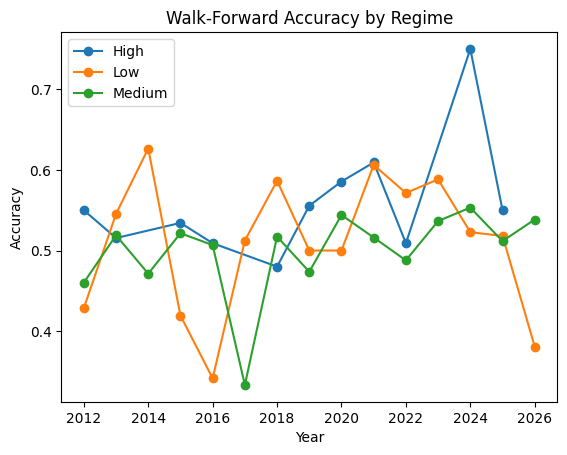

In [15]:
for regime in wf_regime["regime"].unique():
    subset = wf_regime[wf_regime["regime"] == regime]
    plt.plot(subset["year"], subset["accuracy"], marker="o", label=regime)

plt.legend()
plt.title("Walk-Forward Accuracy by Regime")
plt.xlabel("Year")
plt.ylabel("Accuracy")
plt.show()